In [125]:
from google.colab import files
uploaded = files.upload()

Saving 6.jpg to 6 (3).jpg
Saving 12.jpg to 12 (2).jpg
Saving 42.jpg to 42 (2).jpg
Saving 74.jpg to 74 (2).jpg


In [126]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [127]:
def kmeans(data, k=3, max_iter=300, tol=1e-4):
    centroids = data[np.random.choice(len(data), k, replace=False)]

    for _ in range(max_iter):
        distances = np.linalg.norm(data[:, None] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        new_centroids = []
        for i in range(k):
            members = data[labels == i]
            if len(members) == 0:
                new_centroids.append(data[random.randint(0, len(data)-1)])
            else:
                new_centroids.append(members.mean(axis=0))
        new_centroids = np.array(new_centroids)
        if np.allclose(centroids, new_centroids, atol=tol):
            break
        centroids = new_centroids

    return labels, centroids

In [128]:
def extract_with_channel(channel_data, h, w, k=2):
    labels, centers = kmeans(channel_data.reshape(-1, 1).astype(np.float32), k)
    sorted_ids = np.argsort(np.bincount(labels))
    for i in sorted_ids[:2]:
        mask = (labels.reshape((h, w)) == i).astype(np.uint8) * 255
        cleaned = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
        contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        area = sum(cv2.contourArea(c) for c in contours)
        if area > 500:
            return cleaned
    return None

In [129]:
def extract_digit(image_path, k=3):
    image = cv2.imread(image_path)
    img_resized = cv2.resize(image, (300, 300))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    ycrcb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2YCrCb)

    results = []

    # RGB clustering (3D)
    pixels_rgb = img_rgb.reshape(-1, 3).astype(np.float32)
    labels_rgb, _ = kmeans(pixels_rgb, k=k)
    mask_rgb = extract_with_channel(labels_rgb.astype(np.uint8), h, w, k)
    if mask_rgb is not None:
        digit_rgb = np.zeros_like(img_rgb)
        digit_rgb[mask_rgb == 255] = [0, 255, 0]
        results.append(("RGB", digit_rgb))

    # Cr channel (YCrCb)
    mask_cr = extract_with_channel(ycrcb[:, :, 1], h, w, k)
    if mask_cr is not None:
        digit_cr = np.zeros_like(img_rgb)
        digit_cr[mask_cr == 255] = [0, 255, 0]
        results.append(("YCrCb - Cr", digit_cr))

    plt.figure(figsize=(15, 4))
    plt.subplot(1, len(results) + 1, 1)
    plt.imshow(img_rgb)
    plt.title("Original")
    plt.axis('off')

    for i, (label, result_img) in enumerate(results):
        plt.subplot(1, len(results) + 1, i + 2)
        plt.imshow(result_img)
        plt.title(label)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

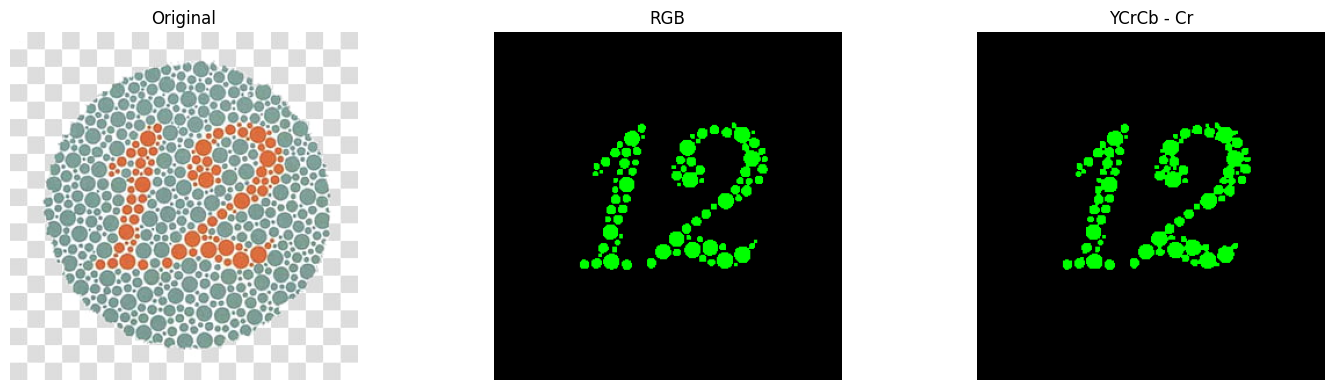

In [130]:
extract_digit("12.jpg",k=5)

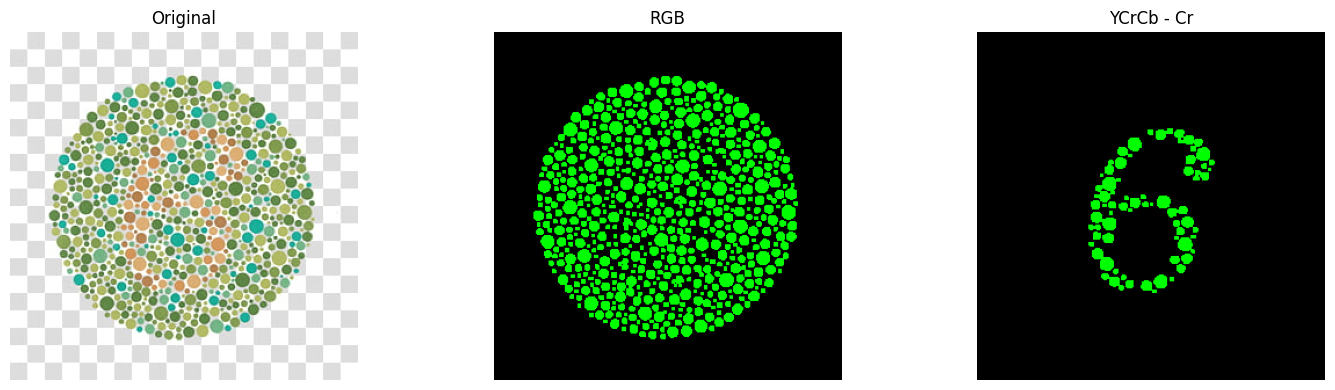

In [131]:
extract_digit("6.jpg",k=3)

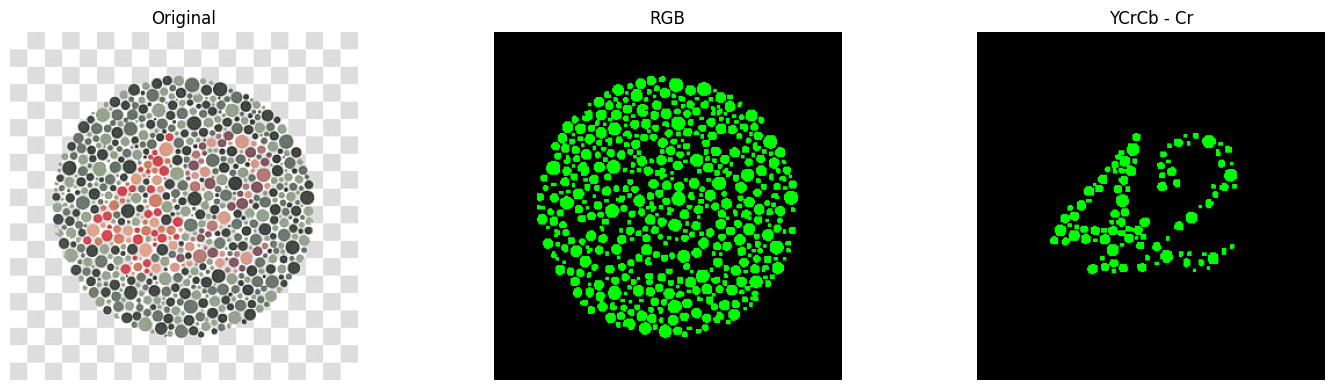

In [132]:
extract_digit("42.jpg",k=3)

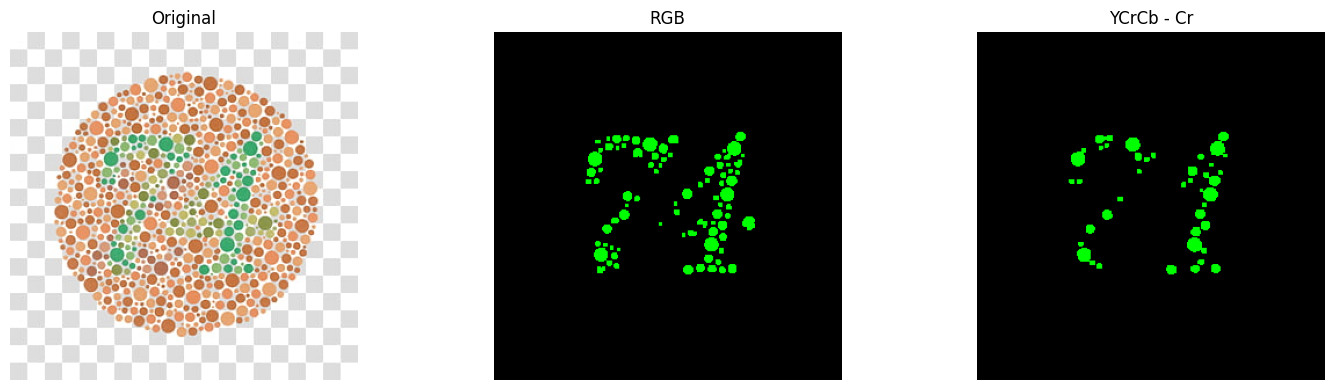

In [135]:
extract_digit("74.jpg",k=6)